# Plant Metadata Assembly — Spain PV Fleet

Builds a clean `plant_metadata.csv` for all utility-scale PV plants in Spain
by combining three sources:

| Source | Provides | Notes |
|--------|----------|-------|
| GEM Global Solar Power Tracker (Feb 2026) | Backbone: name, capacity, lat/lon, technology, commissioning year | 682 operating PV ≥10MW |
| HTML plant database (237 plants) | Cross-check: coordinates, capacity confirmation for large plants | Subset of GEM, used for validation |
| PVGIS API | Optimal tilt angle per location | Free EU API, no auth required |

## Key design decisions

### Tracking type heuristic
No free public source provides tracking type for Spanish PV plants.
We apply: `year >= 2018` → `single_axis`, `year < 2018` → `fixed`.
Rationale: single-axis horizontal trackers became economically dominant in Spain
from ~2018 onwards. Pre-2018 fleet is predominantly fixed-tilt.
Plants with unknown year default to `single_axis` (conservative — most new plants).
This should be acknowledged as an approximation in reporting.

### Capacity threshold
≥10 MW utility-scale only. Below this, individual metering in ESIOS is unlikely
and ERA5 spatial resolution (~11km) is too coarse to be meaningful.

### Tilt fallback
Where PVGIS fails: `tilt ≈ latitude × 0.76 + 3.1°` (Jacobson & Jadhav, 2018).
For single-axis trackers tilt is 0° (horizontal axis) — PVGIS optimal tilt
only applies to fixed systems.

## Output
`spain_total/data/plant_metadata.csv`

## Step 1 — Load & filter GEM

In [13]:
import os, re, time, json, warnings
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

DATA_DIR  = os.path.join(os.getcwd(), 'data')
GEM_PATH  = os.path.join(DATA_DIR, 'Global-Solar-Power-Tracker-February-2026.xlsx')
HTML_PATH = os.path.join(DATA_DIR, 'spain_pv_plants.html')

TRAINING_START = 2023  # earliest year in our dataset

print('Loading GEM...')
gem_raw = pd.read_excel(GEM_PATH, sheet_name='Utility-Scale (1 MW+)')
print(f'GEM total rows: {len(gem_raw)}')

spain = gem_raw[
    (gem_raw['Country/Area'] == 'Spain') &
    (gem_raw['Technology Type'].isin(['PV', 'Assumed PV'])) &
    (gem_raw['Capacity (MW)'] >= 10)
].copy()

# Keep if: currently operating, OR retired but was still active during training period
was_operating = spain['Status'] == 'operating'
retired_during_training = (
    (spain['Status'].str.startswith('retired', na=False)) &
    (spain['Retired year'].fillna(9999) >= TRAINING_START)
)

gem = spain[was_operating | retired_during_training].copy().reset_index(drop=True)

print(f'\nSpain PV >= 10MW active during training period: {len(gem)}')
print(f'  Currently operating: {was_operating.sum()}')
print(f'  Retired but active in {TRAINING_START}+: {retired_during_training.sum()}')
print(f'\nTotal capacity: {gem["Capacity (MW)"].sum():.0f} MW')
print(f'Missing start year: {gem["Start year"].isna().sum()}')
print(f'Missing lat/lon: {gem["Latitude"].isna().sum()}')
gem[['Project Name', 'Capacity (MW)', 'Latitude', 'Longitude', 'Start year', 'Status']].head(8)

Loading GEM...
GEM total rows: 103940

Spain PV >= 10MW active during training period: 682
  Currently operating: 682
  Retired but active in 2023+: 0

Total capacity: 27532 MW
Missing start year: 68
Missing lat/lon: 0


,Project Name,Capacity (MW),Latitude,Longitude,Start year,Status
0,13 Roeles solar farm,14.9,41.3326,-4.9094,2020.0,operating
1,Abertura solar farm,23.0,39.2226,-5.7853,2008.0,operating
2,Abona solar project,17.3,28.1606,-16.4659,2017.0,operating
3,Agenor solar farm,50.0,36.5207,-6.2794,2024.0,operating
4,Ager solar project,11.4,38.3280,-6.6880,2008.0,operating
5,Agripa solar farm,45.3,39.2774,-6.2734,2022.0,operating
6,Aguasvivas solar farm,55.0,41.1471,-0.8656,2024.0,operating
7,Alarcos solar farm,50.0,38.9360,-3.9897,2020.0,operating


## Step 2 — Parse HTML cross-check database

The HTML embeds plant data as a JavaScript array with comments (not valid JSON).
We use regex to extract each plant object and parse field by field.
Used only to cross-validate GEM coordinates for large plants — not as a primary source.

In [14]:
def parse_html_plants(html_path: str) -> pd.DataFrame:
    with open(html_path, 'r', encoding='utf-8') as f:
        html = f.read()

    # Extract the const plants = [...] block
    idx_start = html.find('const plants')
    idx_end   = html.find('];', idx_start) + 2
    block = html[idx_start:idx_end]

    # Remove JS comments (// ...) so we can parse individual objects
    block = re.sub(r'//[^\n]*', '', block)

    # Extract each { ... } object
    records = []
    for m in re.finditer(r'\{([^}]+)\}', block):
        obj_str = m.group(1)
        record  = {}
        for field in re.finditer(r'(\w+)\s*:\s*("[^"]*"|[^,}]+)', obj_str):
            key = field.group(1).strip()
            val = field.group(2).strip().strip('"')
            try:
                val = float(val)
            except ValueError:
                pass
            record[key] = val
        if 'lat' in record and 'lng' in record:
            records.append(record)

    df = pd.DataFrame(records)
    df = df.rename(columns={'lng': 'lon', 'cap': 'capacity_mw_html'})
    return df

html_plants = parse_html_plants(HTML_PATH)
print(f'HTML plants parsed: {len(html_plants)}')
print(f'Columns: {html_plants.columns.tolist()}')
html_plants[['name', 'capacity_mw_html', 'lat', 'lon', 'year']].head(5)

HTML plants parsed: 235
Columns: ['name', 'capacity_mw_html', 'lat', 'lon', 'conf', 'year', 'yconf', 'note']


,name,capacity_mw_html,lat,lon,year
0,ANDASOL-3,149.7,37.229,-3.069,2011.0
1,ASTE 1A,99.8,39.176,-3.234,2012.0
2,ASTEXOL-2,49.9,38.810,-7.053,2012.0
3,CENTRAL SOLAR TERMOELECTRICA ENERSTAR VILLENA,49.9,38.729,-0.922,2013.0
4,CENTRAL TERMOSOLAR LA AFRICANA,49.9,37.755,-5.057,2012.0


## Step 3 — Spatial cross-match GEM vs HTML

For each HTML plant, find the nearest GEM plant within 15 km.
Flag large discrepancies in capacity as potential data quality issues.
This is a validation step — GEM coordinates are kept as the source of truth.

In [15]:
from math import radians, cos, sin, asin, sqrt

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return R * 2 * asin(sqrt(a))

gem_coords = gem[['Latitude', 'Longitude']].values
matched, unmatched = 0, 0
cap_discrepancies = []

for _, row in html_plants.iterrows():
    dists = [haversine_km(row['lat'], row['lon'], g[0], g[1]) for g in gem_coords]
    min_dist = min(dists)
    if min_dist <= 15:
        nearest_idx = dists.index(min_dist)
        gem_cap = gem.iloc[nearest_idx]['Capacity (MW)']
        html_cap = row.get('capacity_mw_html', np.nan)
        if not np.isnan(html_cap) and abs(gem_cap - html_cap) / max(gem_cap, 1) > 0.3:
            cap_discrepancies.append({
                'html_name': row['name'],
                'gem_name':  gem.iloc[nearest_idx]['Project Name'],
                'html_cap':  html_cap,
                'gem_cap':   gem_cap,
                'dist_km':   round(min_dist, 2),
            })
        matched += 1
    else:
        unmatched += 1

print(f'HTML plants matched to GEM (within 15km): {matched}/{len(html_plants)}')
print(f'HTML plants with no GEM match: {unmatched}')
print(f'\nCapacity discrepancies (>30%): {len(cap_discrepancies)}')
if cap_discrepancies:
    print(pd.DataFrame(cap_discrepancies).to_string())

HTML plants matched to GEM (within 15km): 185/235
HTML plants with no GEM match: 50

Capacity discrepancies (>30%): 132
                                         html_name                                          gem_name  html_cap  gem_cap  dist_km
0                                        ANDASOL-3  Valle Del Zalabí Comarca De Guadix solar project   149.700     10.1     1.66
1    CENTRAL SOLAR TERMOELECTRICA ENERSTAR VILLENA                      Vidriera Crisnova solar farm    49.900     12.0     3.20
2                   CENTRAL TERMOSOLAR LA AFRICANA                      Andalusia solar project CXLV    49.900     16.0     6.87
3                                       EXTRESOL-1                              Las Jaras solar farm   149.800     59.0    10.58
4                                        LA DEHESA                          Extremasol solar project    49.900     10.0    12.11
5                                          MAJADAS                      Extremadura solar project CV    49

## Step 4 — Clean GEM and prepare for PVGIS

In [16]:
# Rename GEM columns to our schema
plants = gem[[
    'Project Name', 'Capacity (MW)', 'Latitude', 'Longitude',
    'Start year', 'Technology Type', 'State/Province', 'GEM phase ID'
]].copy()

plants.columns = [
    'plant_name', 'capacity_mw', 'latitude', 'longitude',
    'start_year', 'technology_type', 'province', 'gem_id'
]

# Sequential plant_id
plants.insert(0, 'plant_id', [f'plant_{i+1:03d}' for i in range(len(plants))])

# Tracking type heuristic
# single_axis for 2018+, fixed for pre-2018, single_axis for unknown (new plant assumption)
def assign_tracking(year):
    if pd.isna(year):
        return 'single_axis'
    return 'single_axis' if int(year) >= 2018 else 'fixed'

plants['tracking_type']     = plants['start_year'].apply(assign_tracking)
plants['tracking_imputed']  = True  # all are heuristic — flag for reporting

print(f'Plants: {len(plants)}')
print(f'Tracking distribution:')
print(plants['tracking_type'].value_counts())
print(f'\nStart year missing: {plants["start_year"].isna().sum()}')
plants.head(5)

Plants: 682
Tracking distribution:
tracking_type
single_axis    531
fixed          151
Name: count, dtype: int64

Start year missing: 68


,plant_id,plant_name,capacity_mw,latitude,longitude,start_year,technology_type,province,gem_id,tracking_type,tracking_imputed
0,plant_001,13 Roeles solar farm,14.9,41.3326,-4.9094,2020.0,PV,Castilla y León,G100000827392,single_axis,True
1,plant_002,Abertura solar farm,23.0,39.2226,-5.7853,2008.0,PV,Extremadura,G100000806742,fixed,True
2,plant_003,Abona solar project,17.3,28.1606,-16.4659,2017.0,Assumed PV,Canarias,G100001010605,fixed,True
3,plant_004,Agenor solar farm,50.0,36.5207,-6.2794,2024.0,PV,Andalucía,G100000827402,single_axis,True
4,plant_005,Ager solar project,11.4,38.3280,-6.6880,2008.0,Assumed PV,Extremadura,G100001010483,fixed,True


## Step 5 — Fetch PVGIS optimal tilt per plant

PVGIS returns optimal fixed tilt for each lat/lon.
For single-axis trackers, tilt is set to 0° (horizontal axis) regardless of PVGIS output —
the tracker rotates around a horizontal north-south axis.
Fallback for API failures: `tilt ≈ lat × 0.76 + 3.1°`.

In [17]:
def fetch_pvgis_tilt(lat: float, lon: float) -> dict:
    url = 'https://re.jrc.ec.europa.eu/api/v5_2/PVcalc'
    params = {
        'lat':           lat,
        'lon':           lon,
        'peakpower':     1,
        'loss':          14,
        'optimalangles': 1,
        'outputformat':  'json',
        'browser':       0,
    }
    try:
        resp = requests.get(url, params=params, timeout=30)
        resp.raise_for_status()
        data = resp.json()
        fixed = data.get('inputs', {}).get('mounting_system', {}).get('fixed', {})
        tilt    = fixed.get('slope',   {}).get('value', None)
        azimuth = fixed.get('azimuth', {}).get('value', None)
        return {'tilt_deg': tilt, 'azimuth_deg': azimuth, 'pvgis_ok': True}
    except Exception as e:
        return {'tilt_deg': None, 'azimuth_deg': None, 'pvgis_ok': False}

# Debug: test one plant first
test = fetch_pvgis_tilt(39.30, -5.20)
print('PVGIS test result:', test)

PVGIS test result: {'tilt_deg': 34, 'azimuth_deg': 2, 'pvgis_ok': True}


In [18]:
# Fetch tilt for all plants (~5-6 min with 0.5s sleep)
tilt_results = []

for i, row in plants.iterrows():
    result = fetch_pvgis_tilt(row['latitude'], row['longitude'])
    tilt_results.append(result)
    status = '✓' if result['pvgis_ok'] else '✗'
    if (i + 1) % 50 == 0 or not result['pvgis_ok']:
        print(f'{status} [{i+1}/{len(plants)}] {row["plant_name"][:40]:40s}  '
              f'tilt={result["tilt_deg"]}  az={result["azimuth_deg"]}')
    time.sleep(0.5)

tilt_df = pd.DataFrame(tilt_results)
print(f'\nPVGIS success: {tilt_df["pvgis_ok"].sum()}/{len(tilt_df)}')
print(f'PVGIS failed:  {(~tilt_df["pvgis_ok"]).sum()}')

✓ [50/682] Amazon Zaragoza solar farm                tilt=38  az=-1
✓ [100/682] Belinchón solar farm                      tilt=36  az=-4
✓ [150/682] Cantillana solar project                  tilt=34  az=1
✓ [200/682] Castile-La Mancha solar project CCLVII    tilt=36  az=0
✓ [250/682] Don Quijote solar farm                    tilt=36  az=-2
✓ [300/682] Escatrón Dos solar farm                   tilt=38  az=-1
✓ [350/682] Grullas solar farm                        tilt=34  az=1
✓ [400/682] La Quintana solar project                 tilt=35  az=1
✓ [450/682] Malpartida de Cáceres solar project       tilt=35  az=-2
✓ [500/682] Palma del Río PV solar farm               tilt=35  az=1
✓ [550/682] SEAT al Sol solar project                 tilt=38  az=1
✓ [600/682] Talaván solar farm                        tilt=35  az=-1
✓ [650/682] Valladolid (Sonnedix) solar farm          tilt=36  az=-3

PVGIS success: 682/682
PVGIS failed:  0


In [19]:
# Merge tilt into plants
plants['tilt_deg_pvgis']  = tilt_df['tilt_deg'].values
plants['azimuth_deg']     = tilt_df['azimuth_deg'].values
plants['pvgis_ok']        = tilt_df['pvgis_ok'].values

# Fallback tilt where PVGIS failed
mask_fail = ~plants['pvgis_ok']
plants.loc[mask_fail, 'tilt_deg_pvgis'] = (plants.loc[mask_fail, 'latitude'] * 0.76 + 3.1).round(1)
plants.loc[mask_fail, 'azimuth_deg']    = 0.0  # south-facing default

# For single-axis trackers: tilt = 0 (horizontal axis)
# For fixed: use PVGIS optimal tilt
plants['tilt_deg'] = np.where(
    plants['tracking_type'] == 'single_axis',
    0.0,
    plants['tilt_deg_pvgis']
)

# Azimuth sin/cos encoding (circular — for TFT static reals)
az_rad = np.deg2rad(plants['azimuth_deg'].fillna(0.0))
plants['azimuth_sin'] = np.sin(az_rad)
plants['azimuth_cos'] = np.cos(az_rad)

print('Missing tilt after fill:', plants['tilt_deg'].isna().sum())
print('Missing azimuth after fill:', plants['azimuth_deg'].isna().sum())
print('\nTilt distribution (fixed plants only):')
print(plants[plants['tracking_type']=='fixed']['tilt_deg'].describe())

Missing tilt after fill: 0
Missing azimuth after fill: 0

Tilt distribution (fixed plants only):
count    151.000000
mean      35.086093
std        1.931978
min       26.000000
25%       34.000000
50%       35.000000
75%       36.000000
max       38.000000
Name: tilt_deg, dtype: float64


## Step 6 — Validation plots

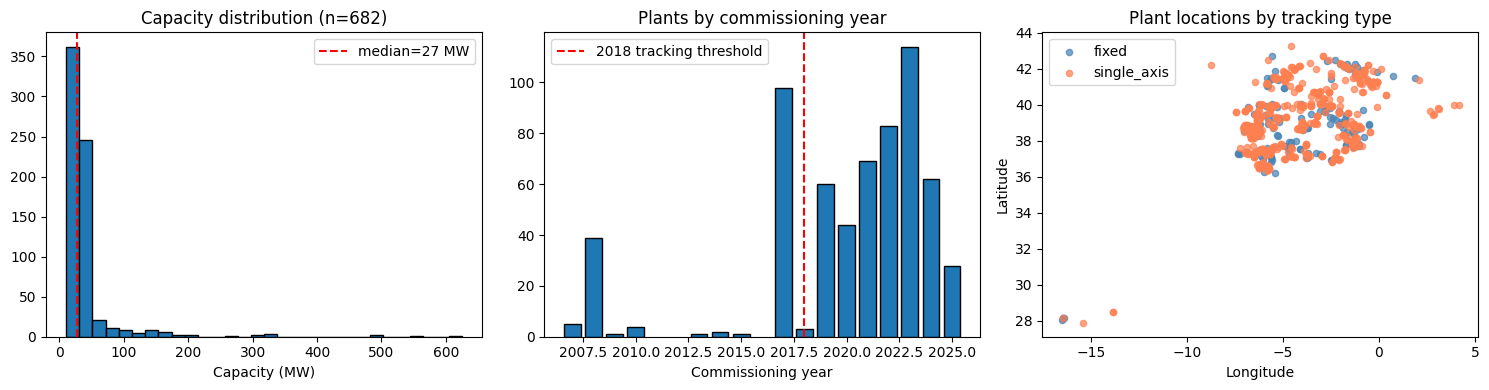

Total capacity: 27532 MW
Tracking type distribution:
tracking_type
single_axis    531
fixed          151
Name: count, dtype: int64

Commissioning year: 2007 – 2025


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Capacity distribution
axes[0].hist(plants['capacity_mw'], bins=30, edgecolor='black')
axes[0].set_xlabel('Capacity (MW)')
axes[0].set_title(f'Capacity distribution (n={len(plants)})')
axes[0].axvline(plants['capacity_mw'].median(), color='red', linestyle='--', label=f'median={plants["capacity_mw"].median():.0f} MW')
axes[0].legend()

# Commissioning year
year_counts = plants['start_year'].dropna().astype(int).value_counts().sort_index()
axes[1].bar(year_counts.index, year_counts.values, edgecolor='black')
axes[1].axvline(2018, color='red', linestyle='--', label='2018 tracking threshold')
axes[1].set_xlabel('Commissioning year')
axes[1].set_title('Plants by commissioning year')
axes[1].legend()

# Geographic distribution
colors = {'single_axis': 'coral', 'fixed': 'steelblue'}
for tracking, group in plants.groupby('tracking_type'):
    axes[2].scatter(group['longitude'], group['latitude'],
                    c=colors[tracking], label=tracking, s=20, alpha=0.7)
axes[2].set_xlabel('Longitude')
axes[2].set_ylabel('Latitude')
axes[2].set_title('Plant locations by tracking type')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f'Total capacity: {plants["capacity_mw"].sum():.0f} MW')
print(f'Tracking type distribution:')
print(plants['tracking_type'].value_counts())
print(f'\nCommissioning year: {plants["start_year"].min():.0f} – {plants["start_year"].max():.0f}')

## Step 7 — Export

In [21]:
save_cols = [
    'plant_id', 'plant_name', 'capacity_mw',
    'latitude', 'longitude', 'province',
    'start_year', 'technology_type',
    'tracking_type', 'tracking_imputed',
    'tilt_deg', 'azimuth_deg', 'azimuth_sin', 'azimuth_cos',
    'pvgis_ok', 'gem_id',
]

output = plants[save_cols].copy()
output_path = os.path.join(DATA_DIR, 'plant_metadata.csv')
output.to_csv(output_path, index=False)

print(f'Saved to: {output_path}')
print(f'Shape: {output.shape}')
print(f'\nColumn summary:')
print(output.dtypes)
print(f'\nMissing values:')
print(output.isnull().sum()[output.isnull().sum() > 0])
print('\nNext step: 1_generation_download.ipynb')

Saved to: c:\Users\nicol\Documents\ML-solar-forecast\spain_total\data\plant_metadata.csv
Shape: (682, 16)

Column summary:
plant_id             object
plant_name           object
capacity_mw         float64
latitude            float64
longitude           float64
province             object
start_year          float64
technology_type      object
tracking_type        object
tracking_imputed       bool
tilt_deg            float64
azimuth_deg           int64
azimuth_sin         float64
azimuth_cos         float64
pvgis_ok               bool
gem_id               object
dtype: object

Missing values:
start_year    68
dtype: int64

Next step: 1_generation_download.ipynb
